# VWAP and TWAP Execution Algorithms

**Docker image**: `ml4t`

This notebook implements the two most common execution benchmarks:

- **TWAP (Time-Weighted Average Price)**: Equal slices over time
- **VWAP (Volume-Weighted Average Price)**: Slices proportional to expected volume

**Learning Objectives**
- Build TWAP and VWAP schedules from execution constraints and volume forecasts
- Simulate realized execution prices against a benchmark VWAP path
- Quantify when VWAP improves benchmark tracking relative to TWAP
- Translate schedule shapes into practical execution guidance

**Book Reference:** Chapter 18: Section 18.5 (Execution Algorithms as Controls)

**Prerequisites:** Read [`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for impact assumptions
and [`05_almgren_chriss_optimal_execution`](05_almgren_chriss_optimal_execution.ipynb) for the transition from control
algorithms to explicit cost-risk optimization.

## Why TWAP and VWAP?

These algorithms serve as:
- **Execution benchmarks**: Performance measured against a declared schedule
- **Impact control**: Spread execution across the available liquidity
- **Market impact control**: Avoid moving markets with large orders
- **Passive strategies**: Execute without alpha view

| Algorithm | Best For | Key Assumption |
|-----------|----------|----------------|
| TWAP | Stable liquidity, weak volume forecast | Equal time slices are acceptable |
| VWAP | Liquid stocks, predictable patterns | Historical volume predicts intraday |

## Imports & Settings

In [1]:
"""VWAP and TWAP Execution - Algorithm implementation and evaluation on real NASDAQ-100 sessions."""

from datetime import datetime, timedelta

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_nasdaq100_bars
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Real AlgoSeek NASDAQ-100 minute bars drive both the volume profile and the
# execution evaluation. The intraday volume forecast is estimated on one window
# and execution is evaluated on a disjoint window so the VWAP forecast is
# strictly out-of-sample.
EXEC_SYMBOL = "AAPL"
TAQ_START_DATE = "2021-10-01"
TAQ_END_DATE = "2021-12-31"
PROFILE_END_DATE = "2021-11-15"
INTERVAL_MINUTES = 15  # execution grid; 09:30-16:00 gives 26 half-open intervals
ORDER_SHARES = 100_000
IMPACT_BPS = 5.0  # illustrative square-root impact coefficient
SEED = 42

In [3]:
set_global_seeds(SEED)

## Part 1: TWAP Algorithm

**TWAP** divides the order equally across time intervals:

$$\text{Trade Size}_t = \frac{\text{Total Order}}{\text{Number of Intervals}}$$

Advantages:
- Simple to implement
- No volume prediction needed
- Avoids relying on an unstable volume forecast

Disadvantages:
- Ignores intraday volume patterns
- May execute at low-volume times (higher impact)

In [4]:
def build_time_grid(
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
) -> list[datetime]:
    """Create the execution clock used by both TWAP and VWAP.

    Each returned timestamp is a *decision time* - the instant a slice is
    scheduled - not the boundary of a closed time interval. Slice volume is
    attributed to the interval beginning at that decision time.
    """
    if interval_minutes <= 0:
        raise ValueError("interval_minutes must be positive")
    if end_time <= start_time:
        raise ValueError("end_time must be later than start_time")
    current = start_time
    times = []
    while current < end_time:
        times.append(current)
        current += timedelta(minutes=interval_minutes)
    return times

### Build the TWAP Share Schedule

In [5]:
def build_twap_schedule(
    total_shares: int,
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
) -> pl.DataFrame:
    """Allocate shares evenly across the available execution intervals."""
    if total_shares <= 0:
        raise ValueError("total_shares must be positive")
    times = build_time_grid(start_time, end_time, interval_minutes)
    n_intervals = len(times)
    shares_per_interval = total_shares // n_intervals
    remainder = total_shares % n_intervals

    schedule = []
    cumulative = 0
    for i, ts in enumerate(times):
        shares = shares_per_interval + (1 if i < remainder else 0)
        cumulative += shares
        schedule.append(
            {
                "timestamp": ts,
                "shares": shares,
                "cumulative": cumulative,
                "pct_complete": cumulative / total_shares,
            }
        )

    return pl.DataFrame(schedule)

### Target Lookup Helper

In [6]:
def latest_cumulative_target(schedule: pl.DataFrame, current_time: datetime) -> int:
    """Return the most recent cumulative target in the schedule."""
    mask = schedule["timestamp"].to_numpy() <= current_time
    if not mask.any():
        return 0
    latest_index = int(np.flatnonzero(mask)[-1])
    return int(schedule["cumulative"].item(latest_index))

### TWAP Summary Helper

In [7]:
def summarize_twap(algo) -> dict:
    """Create a compact TWAP schedule summary."""
    return {
        "algorithm": "TWAP",
        "total_shares": algo.total_shares,
        "n_intervals": len(algo.schedule),
        "interval_minutes": algo.interval_minutes,
        "shares_per_interval": algo.total_shares // len(algo.schedule),
    }

### TWAP Class Definition

In [8]:
class TWAPAlgorithm:
    """Time-Weighted Average Price execution algorithm."""

    def __init__(
        self, total_shares: int, start_time: datetime, end_time: datetime, interval_minutes: int = 5
    ):
        self.total_shares = total_shares
        self.start_time = start_time
        self.end_time = end_time
        self.interval_minutes = interval_minutes
        self.schedule = build_twap_schedule(
            total_shares=self.total_shares,
            start_time=self.start_time,
            end_time=self.end_time,
            interval_minutes=self.interval_minutes,
        )

    def get_target_at_time(self, current_time: datetime) -> int:
        return latest_cumulative_target(self.schedule, current_time)

    def summary(self) -> dict:
        return summarize_twap(self)

In [9]:
# Example TWAP schedule
start = datetime(2024, 1, 15, 9, 30)
end = datetime(2024, 1, 15, 16, 0)

twap = TWAPAlgorithm(
    total_shares=100_000,
    start_time=start,
    end_time=end,
    interval_minutes=15,
)

assert twap.get_target_at_time(start - timedelta(seconds=1)) == 0
assert twap.get_target_at_time(start) == twap.schedule["cumulative"].item(0)
assert twap.get_target_at_time(start + timedelta(minutes=7)) == twap.schedule["cumulative"].item(0)
assert twap.get_target_at_time(twap.schedule["timestamp"].item(-1)) == twap.total_shares

print("TWAP Schedule Summary:")
for k, v in twap.summary().items():
    print(f"  {k}: {v}")

assert twap.schedule["shares"].sum() == twap.total_shares

TWAP Schedule Summary:
  algorithm: TWAP
  total_shares: 100000
  n_intervals: 26
  interval_minutes: 15
  shares_per_interval: 3846


**Finding**: The TWAP summary confirms that the schedule is intentionally blind
to liquidity conditions. Equal slice sizes are a feature when the desk wants
robustness, but they also guarantee trading through the session's thin spots.

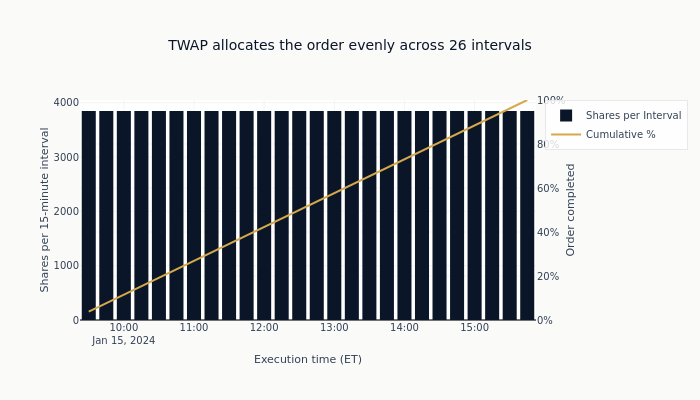

In [10]:
# Visualize the TWAP child orders and completion path.
fig = go.Figure()

times = twap.schedule["timestamp"].to_list()
shares = twap.schedule["shares"].to_list()

fig.add_bar(
    x=times,
    y=shares,
    name="Shares per Interval",
    marker_color=COLORS["blue"],
)

fig.add_scatter(
    x=times,
    y=twap.schedule["pct_complete"].to_list(),
    mode="lines",
    name="Cumulative %",
    yaxis="y2",
    line=dict(color=COLORS["amber"], width=2),
)

fig.update_layout(
    title=f"TWAP allocates the order evenly across {len(twap.schedule)} intervals",
    xaxis_title="Execution time (ET)",
    yaxis_title=f"Shares per {twap.interval_minutes}-minute interval",
    yaxis2=dict(
        title="Order completed",
        overlaying="y",
        side="right",
        tickformat=".0%",
        range=[0, 1],
    ),
    height=400,
)
fig.show()

**Finding**: TWAP creates a flat schedule in share space and a linear ramp in
cumulative completion. That makes the algorithm robust when volume forecasts are
unreliable, but it also guarantees activity during the midday liquidity trough.

## Part 2: VWAP Algorithm

**VWAP** matches the market's volume profile:

$$\text{Trade Size}_t = \text{Total Order} \times \frac{\text{Expected Volume}_t}{\text{Total Expected Volume}}$$

Advantages:
- Reduces impact by trading when liquidity is high
- Better benchmark tracking
- Industry standard for passive execution

Disadvantages:
- Requires volume prediction
- May front-run predictable patterns

### Intraday Volume Patterns from Real Minute Bars

US equity markets exhibit a consistent **U-shaped** volume pattern - high at the
open, thin at midday, high into the close. Rather than assume that shape, we
measure it directly from AlgoSeek NASDAQ-100 minute bars and use the measured
profile as the VWAP volume forecast. We restrict to the regular session
(09:30-16:00) and aggregate minute bars onto the execution grid.

In [11]:
def load_intraday_panel(
    symbols: list[str],
    start_date: str,
    end_date: str,
    interval_minutes: int,
) -> pl.DataFrame:
    """Aggregate minute bars by symbol, session, and execution-grid bucket."""
    session_start = 9 * 60 + 30  # 09:30 as minute-of-day
    session_end = 16 * 60  # 16:00
    panel = (
        load_nasdaq100_bars(
            start_date=start_date,
            end_date=end_date,
            include_microstructure=True,
            lazy=True,
        )
        .filter(pl.col("symbol").is_in(symbols))
        .select("timestamp", "symbol", "volume", "last_trade_price")
        .filter(pl.col("last_trade_price").is_not_null() & (pl.col("volume") > 0))
        .with_columns(
            session_date=pl.col("timestamp").dt.date(),
            minute_of_day=pl.col("timestamp").dt.hour().cast(pl.Int32) * 60
            + pl.col("timestamp").dt.minute().cast(pl.Int32),
        )
        .filter(
            (pl.col("minute_of_day") >= session_start) & (pl.col("minute_of_day") < session_end)
        )
        .with_columns(
            bucket=((pl.col("minute_of_day") - session_start) // interval_minutes).cast(pl.Int32)
        )
        .group_by("symbol", "session_date", "bucket")
        .agg(
            volume=pl.col("volume").sum(),
            price=(pl.col("last_trade_price") * pl.col("volume")).sum() / pl.col("volume").sum(),
        )
        .sort("symbol", "session_date", "bucket")
        .collect()
    )
    return panel

In [12]:
N_BUCKETS = (16 * 60 - (9 * 60 + 30)) // INTERVAL_MINUTES
panel = load_intraday_panel([EXEC_SYMBOL], TAQ_START_DATE, TAQ_END_DATE, INTERVAL_MINUTES)
print(
    f"Loaded {panel.height:,} interval rows for {panel['symbol'].n_unique()} symbols "
    f"across {panel['session_date'].n_unique()} sessions ({N_BUCKETS} intervals per session)"
)

Loaded 1,664 interval rows for 1 symbols across 64 sessions (26 intervals per session)


### Extract Per-Day Price and Volume Paths

Keep only sessions with full interval coverage so each day yields aligned
price and volume arrays of length `N_BUCKETS`.

In [13]:
def day_paths(panel: pl.DataFrame, symbol: str, n_buckets: int) -> dict:
    """Return {session_date: (price_path, volume_path)} for complete sessions."""
    sym = panel.filter(pl.col("symbol") == symbol).sort("session_date", "bucket")
    out = {}
    for d in sym["session_date"].unique().to_list():
        g = sym.filter(pl.col("session_date") == d)
        if g.height == n_buckets:
            out[d] = (g["price"].to_numpy(), g["volume"].to_numpy())
    return out

In [14]:
# Split sessions at a fixed calendar boundary so appending future data cannot
# move the estimation window. The schedule is fixed before execution begins.
profile_symbol = EXEC_SYMBOL
paths_by_day = day_paths(panel, profile_symbol, N_BUCKETS)
all_days = sorted(paths_by_day)
profile_end_date = datetime.fromisoformat(PROFILE_END_DATE).date()
estimation_days = [day for day in all_days if day <= profile_end_date]
execution_days = [day for day in all_days if day > profile_end_date]
if not estimation_days or not execution_days:
    raise ValueError("The fixed profile boundary must leave estimation and execution sessions")

volume_matrix = np.vstack([paths_by_day[d][1] / paths_by_day[d][1].sum() for d in estimation_days])
base_curve = volume_matrix.mean(axis=0)
base_curve = base_curve / base_curve.sum()
print(
    f"{profile_symbol}: {len(estimation_days)} estimation sessions, "
    f"{len(execution_days)} execution sessions"
)

AAPL: 32 estimation sessions, 32 execution sessions


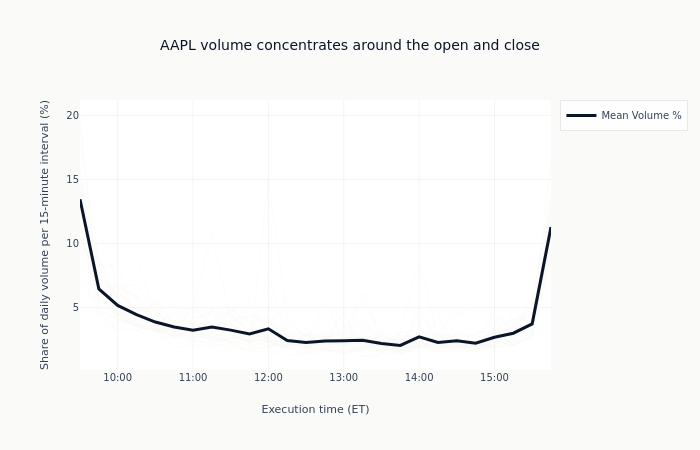

In [15]:
# Plot the measured average profile against the actual per-day realizations.
fig = go.Figure()
bucket_times = build_time_grid(start, end, INTERVAL_MINUTES)
for d in estimation_days:
    daily = paths_by_day[d][1] / paths_by_day[d][1].sum()
    _ = fig.add_scatter(
        x=bucket_times,
        y=daily * 100,
        mode="lines",
        line=dict(width=1, color=COLORS["silver"]),
        opacity=0.4,
        showlegend=False,
    )
_ = fig.add_scatter(
    x=bucket_times,
    y=base_curve * 100,
    mode="lines",
    name="Mean Volume %",
    line=dict(color=COLORS["blue"], width=3),
)
fig.update_layout(
    title=f"{profile_symbol} volume concentrates around the open and close",
    xaxis_title="Execution time (ET)",
    yaxis_title=f"Share of daily volume per {INTERVAL_MINUTES}-minute interval (%)",
    height=450,
)
fig.update_xaxes(tickformat="%H:%M")
fig.show()

In [16]:
open_share = base_curve[: max(1, N_BUCKETS // 6)].sum()
midday_share = base_curve[N_BUCKETS // 3 : 2 * N_BUCKETS // 3].sum()
close_share = base_curve[-max(1, N_BUCKETS // 6) :].sum()
print(f"Open hour:   {open_share:.1%} of volume")
print(f"Midday:      {midday_share:.1%} of volume")
print(f"Close hour:  {close_share:.1%} of volume")

Open hour:   29.6% of volume
Midday:      23.8% of volume
Close hour:  20.7% of volume


**Finding**: The measured profile concentrates volume near the open and close
and thins out midday - the empirical U-shape, not an assumed one. The spread of
the faint per-day lines around the mean is the real day-to-day forecast
uncertainty a VWAP desk faces; it is wider than any smooth parametric curve
would suggest, which is exactly why VWAP tracking is imperfect in practice.

### Volume-Curve Alignment Helper

Resamples any input volume curve onto the execution grid so that VWAP
schedules can consume forecasts at arbitrary granularity.

In [17]:
def normalize_volume_curve(volume_curve: np.ndarray, n_intervals: int) -> np.ndarray:
    """Match any input curve to the target execution grid."""
    curve = np.asarray(volume_curve, dtype=float)
    if curve.ndim != 1 or curve.size == 0:
        raise ValueError("volume_curve must be a non-empty one-dimensional array")
    if not np.isfinite(curve).all() or (curve < 0).any() or curve.sum() <= 0:
        raise ValueError("volume_curve must contain finite nonnegative values with positive sum")
    curve = curve / curve.sum()
    if len(curve) == n_intervals:
        return curve

    aligned_curve = np.interp(
        np.linspace(0, 1, n_intervals),
        np.linspace(0, 1, len(curve)),
        curve,
    )
    return aligned_curve / aligned_curve.sum()

### Convert a Volume Curve into an Execution Schedule

In [18]:
def build_vwap_schedule(
    total_shares: int,
    start_time: datetime,
    end_time: datetime,
    interval_minutes: int,
    volume_curve: np.ndarray,
) -> pl.DataFrame:
    """Allocate shares in proportion to the expected intraday volume profile."""
    if total_shares <= 0:
        raise ValueError("total_shares must be positive")
    times = build_time_grid(start_time, end_time, interval_minutes)
    n_intervals = len(times)
    weights = normalize_volume_curve(volume_curve, n_intervals)
    shares_float = total_shares * weights
    shares_int = np.floor(shares_float).astype(int)

    remainder = total_shares - shares_int.sum()
    if remainder > 0:
        fractions = shares_float - shares_int
        top_idx = np.argsort(fractions)[-int(remainder) :]
        shares_int[top_idx] += 1

    cumulative = np.cumsum(shares_int)
    return pl.DataFrame(
        {
            "timestamp": times,
            "shares": shares_int,
            "volume_weight": weights,
            "cumulative": cumulative,
            "pct_complete": cumulative / total_shares,
        }
    )

### VWAP Summary Helper

In [19]:
def summarize_vwap(algo) -> dict:
    """Create a compact VWAP schedule summary."""
    return {
        "algorithm": "VWAP",
        "total_shares": algo.total_shares,
        "n_intervals": len(algo.schedule),
        "interval_minutes": algo.interval_minutes,
        "max_shares_interval": algo.schedule["shares"].max(),
        "min_shares_interval": algo.schedule["shares"].min(),
    }

### VWAP Class Definition

In [20]:
class VWAPAlgorithm:
    """Volume-Weighted Average Price execution algorithm."""

    def __init__(
        self,
        total_shares: int,
        start_time: datetime,
        end_time: datetime,
        volume_curve: np.ndarray | None = None,
        interval_minutes: int = 5,
    ):
        self.total_shares = total_shares
        self.start_time = start_time
        self.end_time = end_time
        self.interval_minutes = interval_minutes
        if volume_curve is None:
            raise ValueError("VWAP requires a measured volume_curve (the empirical profile).")
        self.schedule = build_vwap_schedule(
            total_shares=self.total_shares,
            start_time=self.start_time,
            end_time=self.end_time,
            interval_minutes=self.interval_minutes,
            volume_curve=volume_curve,
        )
        self.volume_curve = self.schedule["volume_weight"].to_numpy()

    def get_target_at_time(self, current_time: datetime) -> int:
        return latest_cumulative_target(self.schedule, current_time)

    def summary(self) -> dict:
        return summarize_vwap(self)

In [21]:
# Example VWAP schedule, driven by the measured intraday volume profile
vwap = VWAPAlgorithm(
    total_shares=ORDER_SHARES,
    start_time=start,
    end_time=end,
    volume_curve=base_curve,
    interval_minutes=15,
)

assert vwap.get_target_at_time(start - timedelta(seconds=1)) == 0
assert vwap.get_target_at_time(start) == vwap.schedule["cumulative"].item(0)
assert vwap.get_target_at_time(start + timedelta(minutes=7)) == vwap.schedule["cumulative"].item(0)
assert vwap.get_target_at_time(vwap.schedule["timestamp"].item(-1)) == vwap.total_shares

print("VWAP Schedule Summary:")
for k, v in vwap.summary().items():
    print(f"  {k}: {v}")

assert vwap.schedule["shares"].sum() == vwap.total_shares

VWAP Schedule Summary:
  algorithm: VWAP
  total_shares: 100000
  n_intervals: 26
  interval_minutes: 15
  max_shares_interval: 13452
  min_shares_interval: 2059


**Finding**: The VWAP summary is the schedule-level counterpart to the U-curve.
It converts a volume forecast into child-order sizes, which means its quality is
only as good as the forecast feeding it. The example and held-out evaluation
use the same half-open 09:30-16:00 grid.

In [22]:
# Compare TWAP vs VWAP schedules
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Shares per Interval", "Cumulative Execution"],
    vertical_spacing=0.1,
)

# TWAP provides the neutral baseline.
twap_times = twap.schedule["timestamp"].to_list()
_ = fig.add_bar(
    x=twap_times,
    y=twap.schedule["shares"].to_list(),
    name="TWAP",
    marker_color=COLORS["neutral"],
    row=1,
    col=1,
)
_ = fig.add_scatter(
    x=twap_times,
    y=twap.schedule["pct_complete"].to_list(),
    mode="lines",
    name="TWAP Cumulative",
    line=dict(color=COLORS["neutral"], width=2, dash="dash"),
    row=2,
    col=1,
)

#### Add VWAP Schedule Overlay

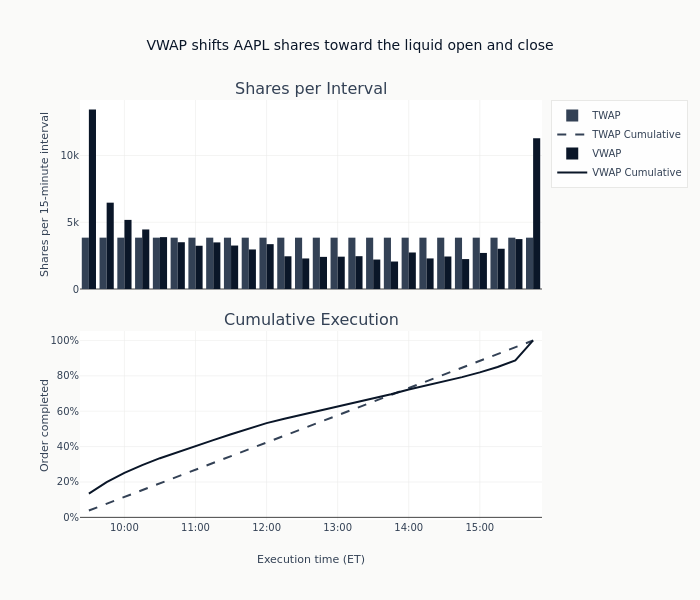

In [23]:
# VWAP is the focal schedule.
vwap_times = vwap.schedule["timestamp"].to_list()
_ = fig.add_bar(
    x=vwap_times,
    y=vwap.schedule["shares"].to_list(),
    name="VWAP",
    marker_color=COLORS["blue"],
    row=1,
    col=1,
)
_ = fig.add_scatter(
    x=vwap_times,
    y=vwap.schedule["pct_complete"].to_list(),
    mode="lines",
    name="VWAP Cumulative",
    line=dict(color=COLORS["blue"], width=2),
    row=2,
    col=1,
)

fig.update_yaxes(tickformat=".0%", row=2, col=1)
fig.update_yaxes(title_text=f"Shares per {INTERVAL_MINUTES}-minute interval", row=1, col=1)
fig.update_yaxes(title_text="Order completed", row=2, col=1)
fig.update_xaxes(title_text="Execution time (ET)", tickformat="%H:%M", row=2, col=1)
fig.update_layout(
    title=f"VWAP shifts {profile_symbol} shares toward the liquid open and close",
    height=600,
    barmode="group",
)
fig.show()

**Finding**: VWAP reduces share count in the lunch-hour trough and shifts risk
toward the opening and closing intervals. Relative to TWAP, it accepts forecast risk
in exchange for lower expected footprint when the market is thin.

## Part 3: Executing Against a Real Trading Day

We now run the TWAP and VWAP schedules against an actual NASDAQ-100 session -
real interval prices and real interval volumes - and measure realized execution
price against that day's market VWAP.

In [24]:
def shares_from_profile(profile: np.ndarray, total_shares: int) -> np.ndarray:
    """Allocate integer shares across intervals in proportion to a profile."""
    if total_shares <= 0:
        raise ValueError("total_shares must be positive")
    weights = normalize_volume_curve(profile, len(profile))
    raw = total_shares * weights
    shares = np.floor(raw).astype(int)
    remainder = total_shares - int(shares.sum())
    if remainder > 0:
        top_idx = np.argsort(raw - shares)[-remainder:]
        shares[top_idx] += 1
    return shares

### Execute a Schedule Against Real Interval Prices and Volumes

Impact uses the interval's **actual market volume** as the participation
denominator under the square-root law: a slice arriving in a high-volume
interval pays less impact than the same slice in the midday lull. This is the
participation-rate edge VWAP is designed to exploit.

In [25]:
def execute_day(
    shares: np.ndarray,
    price_path: np.ndarray,
    volume_path: np.ndarray,
    impact_bps: float,
) -> tuple[float, np.ndarray]:
    """Return (realized VWAP, per-interval execution price) for a share schedule."""
    if not (len(shares) == len(price_path) == len(volume_path)):
        raise ValueError("shares, price_path, and volume_path must have equal length")
    if shares.sum() <= 0 or (shares < 0).any():
        raise ValueError("shares must be nonnegative with a positive total")
    if not np.isfinite(price_path).all() or not np.isfinite(volume_path).all():
        raise ValueError("price and volume paths must be finite")
    if (price_path <= 0).any() or (volume_path < 0).any():
        raise ValueError("prices must be positive and volumes nonnegative")
    interval_volume = np.maximum(volume_path.astype(float), 1.0)
    participation = np.sqrt(np.maximum(shares, 0) / interval_volume)
    exec_price = price_path * (1 + impact_bps / 10000 * participation)
    realized_vwap = float((exec_price * shares).sum() / shares.sum())
    return realized_vwap, exec_price

### Market VWAP Benchmark

The benchmark weights each interval's observed price by its share of realized
market volume. It is used only after the predetermined schedules execute.

In [26]:
def market_vwap_of(price_path: np.ndarray, volume_path: np.ndarray) -> float:
    """Volume-weighted average price actually traded over the session."""
    if len(price_path) != len(volume_path) or len(price_path) == 0:
        raise ValueError("price_path and volume_path must have equal positive length")
    if not np.isfinite(price_path).all() or not np.isfinite(volume_path).all():
        raise ValueError("price and volume paths must be finite")
    if (price_path <= 0).any() or (volume_path < 0).any() or volume_path.sum() <= 0:
        raise ValueError("prices must be positive and volumes nonnegative with positive total")
    return float((price_path * volume_path).sum() / volume_path.sum())

In [27]:
# Build the two schedules on the execution grid and run them against one real day.
twap_shares = shares_from_profile(np.ones(N_BUCKETS), ORDER_SHARES)
vwap_shares = shares_from_profile(base_curve, ORDER_SHARES)

demo_day = execution_days[0]
demo_price, demo_volume = paths_by_day[demo_day]

market_vwap = market_vwap_of(demo_price, demo_volume)
twap_realized, twap_exec_price = execute_day(twap_shares, demo_price, demo_volume, IMPACT_BPS)
vwap_realized, vwap_exec_price = execute_day(vwap_shares, demo_price, demo_volume, IMPACT_BPS)

twap_vs_benchmark = (twap_realized / market_vwap - 1) * 10000
vwap_vs_benchmark = (vwap_realized / market_vwap - 1) * 10000

print(f"Session: {demo_day} ({profile_symbol})")
print("=" * 50)
print(f"Market VWAP:    ${market_vwap:.4f}")
print(f"TWAP Realized:  ${twap_realized:.4f} ({twap_vs_benchmark:+.1f} bps vs VWAP)")
print(f"VWAP Realized:  ${vwap_realized:.4f} ({vwap_vs_benchmark:+.1f} bps vs VWAP)")

Session: 2021-11-16 (AAPL)
Market VWAP:    $150.6400
TWAP Realized:  $150.7784 (+9.2 bps vs VWAP)
VWAP Realized:  $150.6032 (-2.4 bps vs VWAP)


**Finding**: On this real session the benchmark comparison separates schedule
quality from market direction. The absolute benchmark gaps identify the closer
schedule; neither schedule forecasts price direction.

In [28]:
# Visualize execution against the real session
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price Path & Executions", "Cumulative Fill"],
    vertical_spacing=0.1,
)

_ = fig.add_scatter(
    x=bucket_times,
    y=demo_price,
    mode="lines",
    name="Market Price",
    line=dict(color=COLORS["neutral"], width=1),
    row=1,
    col=1,
)

#### Realized Benchmark Comparison

In [29]:
for name, value, color, dash in (
    ("Market VWAP", market_vwap, COLORS["amber"], "dash"),
    (f"TWAP realized ({twap_vs_benchmark:+.1f} bps)", twap_realized, COLORS["neutral"], "dot"),
    (f"VWAP realized ({vwap_vs_benchmark:+.1f} bps)", vwap_realized, COLORS["blue"], "dash"),
):
    fig.add_scatter(
        x=[bucket_times[0], bucket_times[-1]],
        y=[value, value],
        mode="lines",
        name=name,
        line=dict(color=color, width=2, dash=dash),
        row=1,
        col=1,
    )

#### Cumulative Fill Comparison

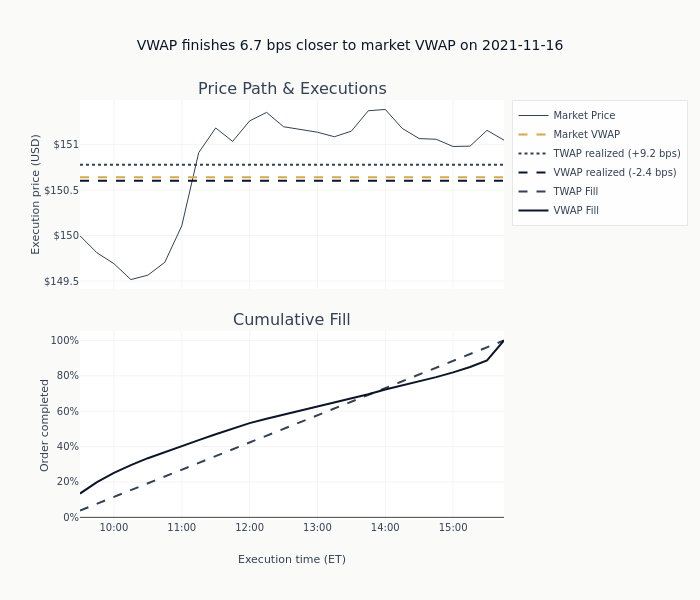

In [30]:
_ = fig.add_scatter(
    x=bucket_times,
    y=np.cumsum(twap_shares) / ORDER_SHARES,
    mode="lines",
    name="TWAP Fill",
    line=dict(color=COLORS["neutral"], width=2, dash="dash"),
    row=2,
    col=1,
)
_ = fig.add_scatter(
    x=bucket_times,
    y=np.cumsum(vwap_shares) / ORDER_SHARES,
    mode="lines",
    name="VWAP Fill",
    line=dict(color=COLORS["blue"], width=2),
    row=2,
    col=1,
)
fig.update_xaxes(title_text="Execution time (ET)", tickformat="%H:%M", row=2, col=1)
fig.update_yaxes(title_text="Execution price (USD)", tickprefix="$", row=1, col=1)
fig.update_yaxes(title_text="Order completed", tickformat=".0%", row=2, col=1)
demo_tracking_gain = abs(twap_vs_benchmark) - abs(vwap_vs_benchmark)
demo_winner = "VWAP" if demo_tracking_gain > 0 else "TWAP"
fig.update_layout(
    title=(
        f"{demo_winner} finishes {abs(demo_tracking_gain):.1f} bps closer to market VWAP "
        f"on {demo_day}"
    ),
    height=600,
)
fig.show()

**Finding**: VWAP clusters fills around the high-liquidity open and close
buckets. The computed title identifies which fixed schedule lands closer to
market VWAP on this session; that difference is benchmark slippage, not alpha.

## Part 4: Cross-Session Distribution

A single session can favor either schedule by luck. We run both schedules across
every held-out execution session and compare the *distribution* of slippage
versus each day's market VWAP. The volume profile feeding VWAP was estimated on
the earlier window, so this is an out-of-sample test of the forecast.

In [31]:
def run_across_days(
    days: list,
    paths: dict,
    twap_shares: np.ndarray,
    vwap_shares: np.ndarray,
    impact_bps: float,
) -> pl.DataFrame:
    """Execute both schedules on each real session and collect slippage vs VWAP."""
    rows = []
    for d in days:
        price_path, volume_path = paths[d]
        mkt = market_vwap_of(price_path, volume_path)
        twap_realized, _ = execute_day(twap_shares, price_path, volume_path, impact_bps)
        vwap_realized, _ = execute_day(vwap_shares, price_path, volume_path, impact_bps)
        rows.append(
            {
                "session_date": d,
                "twap_vs_market_bps": (twap_realized / mkt - 1) * 10000,
                "vwap_vs_market_bps": (vwap_realized / mkt - 1) * 10000,
            }
        )
    return pl.DataFrame(rows)

In [32]:
session_results = run_across_days(
    execution_days,
    paths_by_day,
    twap_shares,
    vwap_shares,
    IMPACT_BPS,
)

**Finding**: The cross-session distribution matters more than any single day.
Signed mean slippage measures bias, while standard deviation, mean absolute error,
and the worst absolute deviation measure how tightly a schedule tracks the benchmark.

### Benchmark Tracking Metrics

A schedule can have a favorable signed bias while missing the benchmark widely.
We therefore report bias separately from distance-based tracking errors.

In [33]:
def summarize_tracking(results: pl.DataFrame) -> pl.DataFrame:
    """Summarize signed bias and distance from market VWAP for each schedule."""
    rows = []
    for algorithm in ("TWAP", "VWAP"):
        values = results[f"{algorithm.lower()}_vs_market_bps"].to_numpy()
        rows.append(
            {
                "algorithm": algorithm,
                "mean_bias_bps": values.mean(),
                "tracking_std_bps": values.std(ddof=1),
                "mae_bps": np.abs(values).mean(),
                "rmse_bps": np.sqrt(np.mean(values**2)),
                "worst_abs_bps": np.abs(values).max(),
            }
        )
    return pl.DataFrame(rows)

In [34]:
tracking_summary = summarize_tracking(session_results)
print(f"Held-out tracking summary: {session_results.height} {profile_symbol} sessions")
tracking_summary

Held-out tracking summary: 32 AAPL sessions


algorithm,mean_bias_bps,tracking_std_bps,mae_bps,rmse_bps,worst_abs_bps
str,f64,f64,f64,f64,f64
"""TWAP""",0.446353,15.931993,11.206456,15.687431,53.218595
"""VWAP""",-1.812069,12.29987,7.180664,12.241024,45.031748


In [35]:
# Visualize results
fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=["TWAP", "VWAP"],
)

all_slippage = np.concatenate(
    [
        session_results["twap_vs_market_bps"].to_numpy(),
        session_results["vwap_vs_market_bps"].to_numpy(),
    ]
)
hist_start = float(np.floor(all_slippage.min() / 5) * 5)
hist_end = float(np.ceil(all_slippage.max() / 5) * 5)
bin_size = max(5.0, (hist_end - hist_start) / 12)

_ = fig.add_histogram(
    x=session_results["twap_vs_market_bps"].to_list(),
    xbins=dict(start=hist_start, end=hist_end, size=bin_size),
    name="TWAP",
    marker_color=COLORS["neutral"],
    row=1,
    col=1,
)

_ = fig.add_histogram(
    x=session_results["vwap_vs_market_bps"].to_list(),
    xbins=dict(start=hist_start, end=hist_end, size=bin_size),
    name="VWAP",
    marker_color=COLORS["blue"],
    row=1,
    col=2,
)

#### Shared Benchmark and Bias Markers

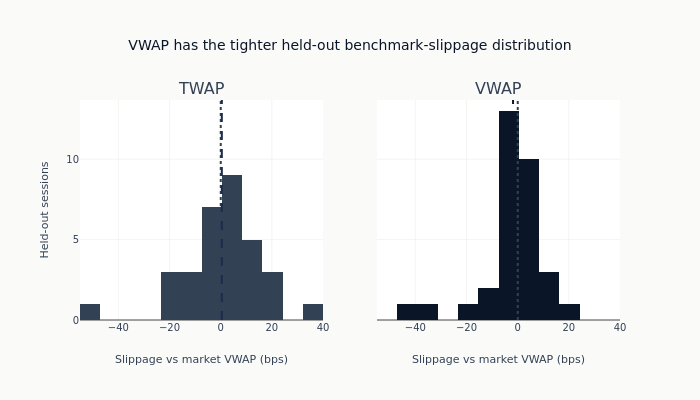

In [36]:
# Zero is exact benchmark tracking; colored dashed lines show signed bias.
twap_mean = session_results["twap_vs_market_bps"].mean()
vwap_mean = session_results["vwap_vs_market_bps"].mean()
for column in (1, 2):
    fig.add_vline(x=0, line_dash="dot", line_color=COLORS["neutral"], row=1, col=column)

fig.add_vline(x=twap_mean, line_dash="dash", line_color=COLORS["slate"], row=1, col=1)
fig.add_vline(x=vwap_mean, line_dash="dash", line_color=COLORS["blue"], row=1, col=2)

fig.update_xaxes(title_text="Slippage vs market VWAP (bps)", range=[hist_start, hist_end])
fig.update_yaxes(title_text="Held-out sessions", row=1, col=1)
tracking_winner = tracking_summary.sort("tracking_std_bps")["algorithm"][0]
fig.update_layout(
    title=f"{tracking_winner} has the tighter held-out benchmark-slippage distribution",
    height=400,
    showlegend=False,
)
fig.show()

**Finding**: The shared axes and zero lines make benchmark distance comparable.
The computed title identifies the tighter held-out distribution; that is evidence
about tracking, not alpha or a guarantee of lower cost on every session.

## Part 5: When to Use TWAP vs VWAP

### Use TWAP When:
- Volume patterns are unpredictable
- Intraday liquidity is reasonably stable
- Schedule certainty and auditability matter
- Simple, robust execution needed

### Use VWAP When:
- Volume patterns are predictable
- Tracking VWAP benchmark matters
- Stock is liquid with stable patterns
- Reducing market impact is priority

### Hybrid Approaches:
- **Adaptive VWAP**: Update volume predictions intraday
- **Percent of Volume (POV)**: Maintain constant participation rate
- **Implementation Shortfall**: Optimize for IS, not VWAP

## Key Takeaways

1. **Impact is participation-rate driven**: Because each
   slice's impact scales with $\sqrt{\text{shares}/\text{interval volume}}$,
   VWAP's volume-tracking schedule reduces modeled impact by routing more shares into
   high-liquidity intervals - the mechanism the cross-session test quantifies.

2. **VWAP trades simplicity for forecast dependence**: Matching the historical
   profile can tighten benchmark tracking only when that volume forecast remains
   reliable. A bad volume forecast erases the advantage.

3. **Neither algorithm "beats the market"**: TWAP and VWAP are
   benchmark-tracking schedules, not alpha strategies. Choosing between
   them is a risk-management decision about execution-cost variance.

**Next**: `05_almgren_chriss_optimal_execution` derives the cost-variance
optimal trajectory; `08_ml_dynamic_execution` makes the schedule adaptive.